In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
import os
import sys
import itertools

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, DoubleType, IntegerType
)
from scipy.stats import kruskal

# Paksa PySpark pakai Python interpreter yang sama dengan Jupyter
# Tanpa ini, PySpark bisa error karena pakai Python versi berbeda
os.environ['PYSPARK_PYTHON']        = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [2]:
# ============================================================
# CELL 2: INISIALISASI MESIN SPARK
# ============================================================
print("=== Menyalakan Mesin Spark ===")

spark = SparkSession.builder \
    .appName("AnalisisPopularitasStudio") \
    .master("local[*]") \
    .config("spark.driver.memory",       "4g") \
    .config("spark.executor.memory",     "4g") \
    .config("spark.driver.maxResultSize","2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("=== Mesin Spark Berhasil Dinyalakan ===")

=== Menyalakan Mesin Spark ===
=== Mesin Spark Berhasil Dinyalakan ===


In [ ]:
# ============================================================
# CELL 3: BACA DATA & EKSTRAKSI (PYSPARK)
# ============================================================

# path_data_bersih = "E:/kodingan_saya/anime-analisis/data/processed/anime_dataset_pre.csv"
path_data_bersih = "../data/processed/anime_dataset_pre2.csv"

# TAHAP 1: Schema manual → Spark tidak scan file dua kali → hindari buffer error
schema = StructType([
    StructField("title",      StringType(),  True),
    StructField("popularity", DoubleType(),  True),
    StructField("favorites",  DoubleType(),  True),
    StructField("studios",    IntegerType(), True),
])

print("\n>>> Mengintip 5 data teratas hasil preprocessing:")
df = spark.read.csv(path_data_bersih, header=True, schema=schema)
df.show(5)

# TAHAP 2: Ambil daftar studio unik (untuk info)
daftar_studio = [
    row['studios'] for row in df.select('studios').distinct().collect()
    if row['studios'] is not None
]
print(f"Ditemukan {len(daftar_studio)} studio unik untuk dianalisis.")

# TAHAP 3: Kelompokkan popularitas per studio dalam SATU query
# Jauh lebih efisien dari loop — Spark hanya scan data sekali
hasil = (
    df.groupBy('studios')
      .agg(
          F.collect_list('popularity').alias('skor_popularitas'),
          F.count('popularity').alias('jumlah')
      )
      .filter(F.col('jumlah') >= 10)   # hanya studio dengan ≥10 anime
      .collect()
)

# Pisahkan hasil ke dua list paralel dengan indeks yang sinkron
# indeks ke-i di kedua list selalu merujuk ke studio yang sama
kelompok_popularitas_full_population = [row['skor_popularitas'] for row in hasil]
groups_filtered_for_test             = [row['studios']          for row in hasil]

# TAHAP 4: Matikan Spark — data sudah di memori Python, tidak dibutuhkan lagi
spark.stop()
print(f"\nBerhasil mengekstrak {len(groups_filtered_for_test)} studio untuk dianalisis.")
print("=== Proses PySpark Selesai. Masuk ke Pengujian SciPy ===")


>>> Mengintip 5 data teratas hasil preprocessing:
+--------------------+--------------------+--------------------+-------+
|               title|          popularity|           favorites|studios|
+--------------------+--------------------+--------------------+-------+
|        Cowboy Bebop|0.001336273134228...|  0.3562386044252649|   1635|
|Cowboy Bebop: Ten...| 0.02194828622970535|0.007094118490091323|    234|
|              Trigun|   0.008819402685909| 0.07010517767144119|    856|
|  Witch Hunter Robin| 0.06641277477116322|0.002814557672555873|   1635|
|      Bouken Ou Beet| 0.19676621901516672|7.165776252617498E-5|   1751|
+--------------------+--------------------+--------------------+-------+
only showing top 5 rows
Ditemukan 2018 studio unik untuk dianalisis.

Berhasil mengekstrak 292 studio untuk dianalisis.
=== Proses PySpark Selesai. Masuk ke Pengujian SciPy ===


In [ ]:
# ============================================================
# CELL 4: ANALISIS PANDAS & UJI KRUSKAL-WALLIS
# ============================================================

# TAHAP 1: Konversi ke Long-Format DataFrame
# itertools.chain.from_iterable "meratakan" list of list menjadi list tunggal
# zip() menjamin studios dan popularity selalu berpasangan dengan benar
df_viz_full = pd.DataFrame({
    'studios': list(itertools.chain.from_iterable(
        [sid] * len(scores)
        for sid, scores in zip(groups_filtered_for_test,
                               kelompok_popularitas_full_population)
    )),
    'popularity': list(itertools.chain.from_iterable(
        kelompok_popularitas_full_population
    ))
})

# TAHAP 2: Ambil Top 10 studio paling populer
# "popularity" = skor rank → nilai KECIL = lebih populer
# ascending=True + head(10) → ambil 10 median terkecil = paling populer
top_10_ids = (
    df_viz_full.groupby('studios')['popularity']
               .median()
               .sort_values(ascending=True)
               .head(10)
               .index.tolist()
)

# TAHAP 3: Hitung statistik deskriptif Top 10
top_10_summary_stats = (
    df_viz_full[df_viz_full['studios'].isin(top_10_ids)]
    .groupby('studios')
    .agg(
        N       =('popularity', 'count'),
        Median  =('popularity', 'median'),
        Mean    =('popularity', 'mean'),
        Std_Dev =('popularity', 'std')
    )
    .reindex(top_10_ids)   # urutkan sesuai top_10_ids (kecil ke besar)
    .reset_index()
)

# TAHAP 4: Siapkan DataFrame & urutan kategori untuk visualisasi
df_viz_top10 = df_viz_full[df_viz_full['studios'].isin(top_10_ids)].copy()
category_order = top_10_summary_stats['studios'].astype(str).tolist()
df_viz_top10['studios'] = pd.Categorical(
    df_viz_top10['studios'].astype(str),
    categories=category_order,
    ordered=True
)

# TAHAP 5: Uji Kruskal-Wallis — hanya pada Top 10
# Kruskal-Wallis menguji apakah ≥1 studio punya distribusi popularitas berbeda
# H0: semua studio memiliki distribusi yang sama
# * unpacking (*) mengubah list of list menjadi argumen terpisah per studio
kelompok_top10 = [
    kelompok_popularitas_full_population[i]
    for i, sid in enumerate(groups_filtered_for_test)
    if sid in top_10_ids
]
h_stat, p_value = kruskal(*kelompok_top10)

print(f"Nilai H-Statistic : {h_stat:.4f}")
print(f"Nilai P-Value     : {p_value:.6f}")

Nilai H-Statistic : 9.0032
Nilai P-Value     : 0.436981


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24264\2289543174.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24264\2289543174.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


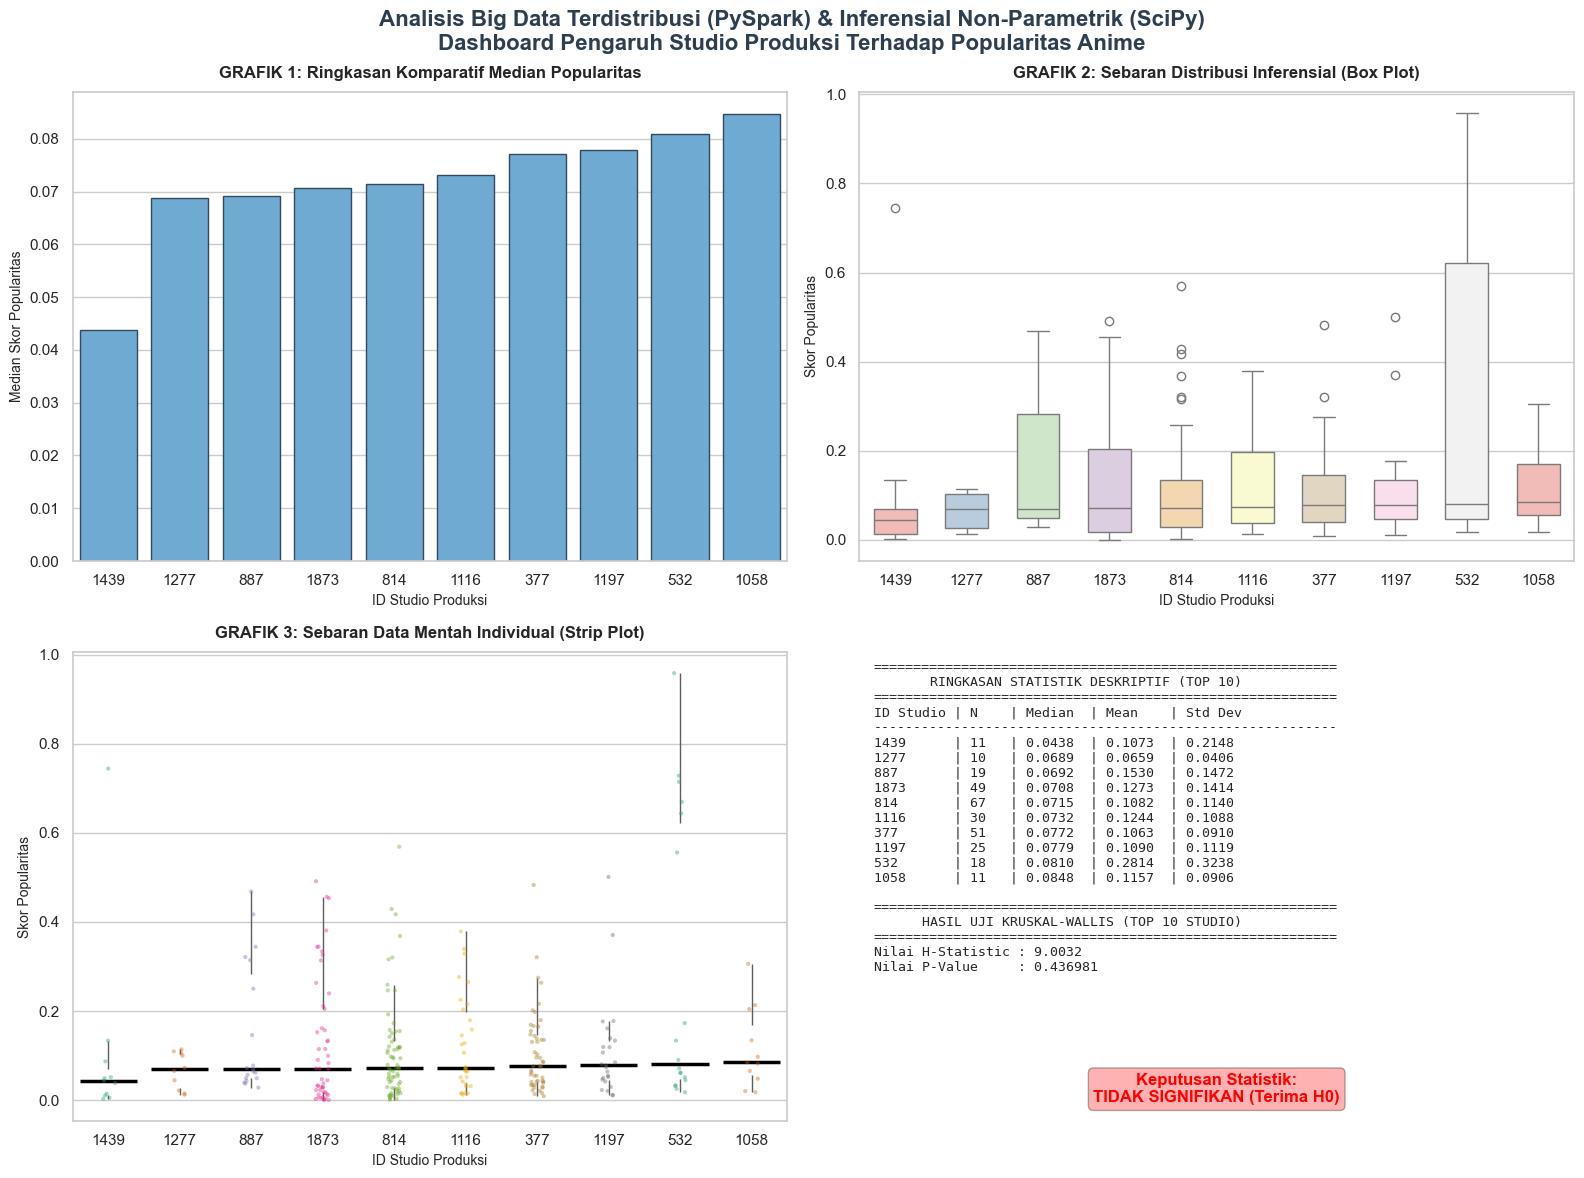

In [7]:
# ============================================================
# CELL 5: VISUALISASI DASHBOARD
# ============================================================
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.suptitle(
    'Analisis Big Data Terdistribusi (PySpark) & Inferensial Non-Parametrik (SciPy)\n'
    'Dashboard Pengaruh Studio Produksi Terhadap Popularitas Anime',
    fontsize=16, fontweight='bold', color='#2c3e50'
)

# ── GRAFIK 1: Bar Chart Median ──────────────────────────────
ax1 = axes[0, 0]
sns.barplot(
    x='studios', y='Median', data=top_10_summary_stats,
    color='#5dade2', edgecolor='#34495e', ax=ax1, order=category_order
)
ax1.set_title('GRAFIK 1: Ringkasan Komparatif Median Popularitas',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('ID Studio Produksi', fontsize=10)
ax1.set_ylabel('Median Skor Popularitas', fontsize=10)

# ── GRAFIK 2: Box Plot ──────────────────────────────────────
ax2 = axes[0, 1]
sns.boxplot(
    x='studios', y='popularity', data=df_viz_top10,
    palette='Pastel1', ax=ax2, order=category_order,
    showfliers=True, width=0.6
)
ax2.set_title('GRAFIK 2: Sebaran Distribusi Inferensial (Box Plot)',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('ID Studio Produksi', fontsize=10)
ax2.set_ylabel('Skor Popularitas', fontsize=10)

# ── GRAFIK 3: Strip Plot + Median Line ─────────────────────
ax3 = axes[1, 0]
sns.stripplot(
    x='studios', y='popularity', data=df_viz_top10,
    palette='Dark2', ax=ax3, order=category_order,
    jitter=True, size=3, alpha=0.4
)
sns.boxplot(
    x='studios', y='popularity', data=df_viz_top10,
    ax=ax3, order=category_order,
    showfliers=False, showbox=False, showcaps=False,
    medianprops={"color": "black", "linewidth": 2.5}
)
ax3.set_title('GRAFIK 3: Sebaran Data Mentah Individual (Strip Plot)',
              fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('ID Studio Produksi', fontsize=10)
ax3.set_ylabel('Skor Popularitas', fontsize=10)

# ── GRAFIK 4: Tabel Statistik & Keputusan ──────────────────
ax4 = axes[1, 1]
ax4.axis('off')

stats_text  = "=" * 58 + "\n"
stats_text += "       RINGKASAN STATISTIK DESKRIPTIF (TOP 10)       \n"
stats_text += "=" * 58 + "\n"
stats_text += f"{'ID Studio':<10}| {'N':<5}| {'Median':<8}| {'Mean':<8}| Std Dev\n"
stats_text += "-" * 58 + "\n"
for _, row in top_10_summary_stats.iterrows():
    stats_text += (
        f"{str(int(row['studios'])):<10}| "
        f"{int(row['N']):<5}| "
        f"{row['Median']:<8.4f}| "
        f"{row['Mean']:<8.4f}| "
        f"{row['Std_Dev']:.4f}\n"
    )
stats_text += "\n" + "=" * 58 + "\n"
stats_text += "      HASIL UJI KRUSKAL-WALLIS (TOP 10 STUDIO)       \n"
stats_text += "=" * 58 + "\n"
stats_text += f"Nilai H-Statistic : {h_stat:.4f}\n"
stats_text += f"Nilai P-Value     : {p_value:.6f}\n"

decision_color = "green" if p_value < 0.05 else "red"
decision_text  = "SIGNIFIKAN (Tolak H0)"   if p_value < 0.05 \
            else "TIDAK SIGNIFIKAN (Terima H0)"

ax4.text(0.02, 0.98, stats_text,
         transform=ax4.transAxes, fontsize=9.5,
         fontfamily='monospace', va='top')

props = dict(boxstyle='round', facecolor=decision_color, alpha=0.3, edgecolor='black')
ax4.text(0.5, 0.04,
         f"Keputusan Statistik:\n{decision_text}",
         transform=ax4.transAxes, fontsize=12,
         fontweight='bold', color=decision_color,
         ha='center', bbox=props)

plt.tight_layout()
plt.show()